What is (B,T,C):

B - Batch_size - How many sequences are processed in parallel
T - Time / Sequence_length / Block_size - How many tokens are in one sequence
C - Channels / Classes / Vocab_size - Number of all unique tokens in vocabulary
Why "Time"(T)?
Even though we are dealing with text, we call this dimension "Time" because language models are sequential — they process tokens one after another, like time steps. This naming comes from Recurrent Neural Networks (RNNs) and is still used in Transformers and all modern language models. T=1 → only one token, T=8 → 8 tokens in context, T=1024 → long context (like in GPT models)

Why "Channels"(C)?
"Channels" is a term borrowed from Computer Vision. In images: channels = RGB (3 channels). In language: channels = vocabulary size. Each position has a vector with one number (logit) for every possible token in the vocabulary. That’s why C = vocab_size.

In [30]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [31]:
torch.manual_seed(1337)

# hyperparameters

When we train the Transformer, we do not feed the whole text at once (computationaly expensive). Instead, we sample random little chunks out of the set and train on chunks. These chunks have block_size = the maximum length of the chunk, or context length. And they have batch_size = how many chunks will be fed in parallel.

In [32]:
batch_size = 64  # how many examples per batch
block_size = 256  # input context size
max_iters = 5000  # how many steps to train
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda. is_available() else 'cpu'
eval_iters = 200  # per how many iterations to calculate the loss
n_embd = 384  # number of embedded dimensions
n_head = 6  # how many heads for multi-head attention
n_layer = 6 
dropout = 0.2

# dataset

In [33]:
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
# read the ds
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# vocabulary 

In [34]:
chars = sorted(list(set(text)))  # sorted list of chars
vocab_size = len(chars)

# look-up table

In [35]:
# (from characters/strings to integers)
## enumerate() - if chars is this list ['h', 'e', 'y'], enumerate gives pairs of (position, character): (0, 'h'), (1, 'e'), (2, 'y')
## for i,ch - for every pair (e.g., (0, 'h')), call the number i and the letter ch
## {ch:i} - create a dictionary (key = character, value = number)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}

# encoder & decoder

In [36]:
# encoder: take a string, output a list of integers
## lambda s: [] - create a small function that takes s (a string) and create a list
## stoi[c] for c in s - in that list, apply stoi to each character in a string
encode = lambda s: [stoi[c] for c in s]

# decoder: take a list of integers, output a string
##''.join() - take all those characters and glue them together into one string
decode = lambda l: ''.join([itos[i] for i in l])

# train & test splits

In [37]:
# encode ds & store it into a torch.tensor
data = torch.tensor(encode(text), dtype = torch.long)

# split up data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading (input & output)
**Example in one batch (batch_size=4, block_size=8):**  

*inputs:*  
torch.Size([4, 8])  
tensor([[24, 43, 58,  5, 57,  1, 46, 43],  
        [44, 53, 56,  1, 58, 46, 39, 58],  
        [52, 58,  1, 58, 46, 39, 58,  1],  
        [25, 17, 27, 10,  0, 21,  1, 54]])  

*targets:*  
torch.Size([4, 8])  
tensor([[43, 58,  5, 57,  1, 46, 43, 39],  
        [53, 56,  1, 58, 46, 39, 58,  1],  
        [58,  1, 58, 46, 39, 58,  1, 46],  
        [17, 27, 10,  0, 21,  1, 54, 39]])  

*In context1 (row 1):*  
when input is [24] the target: 43  
when input is [24, 43] the target: 58  
when input is [24, 43, 58] the target: 5  
when input is [24, 43, 58, 5] the target: 57  
when input is [24, 43, 58, 5, 57] the target: 1  
when input is [24, 43, 58, 5, 57, 1] the target: 46  
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43  
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39  

In [38]:
# combine random chunks into batches of size N and prepare the correct output, also the same size.
# (if input is word index xN, output is word index xN+1)

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data  # if there is a split, use train data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

# average loss over multiple batches


In [39]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits,loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

# single-head attention
In self-attention, instead of working with the full embedding size (n_embd), we often split the attention into multiple smaller "heads" (this is called Multi-Head Attention). So, if n_embd = total embedding dimension, then head_size = dimension per head. Typical relationship: head_size = n_embd // num_heads. For example, in small GPT: n_embd=384, num_heads=6, head_size=64. Why? Because smaller matrices = faster computation and less memory. Also, each head can learn to focus on different types of patterns. 


In [40]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()
        # Key, Query, Value:
        # in case of the multi-head attention, we split the full embedding size (for K,Q,V) into smaller "heads".
        # this is done by projecting the embedding dimensions to a smaller per-head dimensions (n_embd → head_size)
        # (n_embd - number of embedded dimensions (e.g., 32); head_size - dimension per head)
        # for this, we create linear layers with weight_matrix of size (head_size, n_embd), without bias
        # so when in forward() we perform matrix multiplication (output = x @ weight_matrix.T, the output is exactly of size head_size.
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # masked self-attention:
        # torch.ones(block_size, block_size) - create a square matrix full of 1s
        # torch.tril() - keep only the lower triangular part (including diagonal), sets upper part to 0
        # register_buffer() - register a tensor as a persistent buffer (saved with the model), callable as 'tril'
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        # dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # we start from x=(B,T,C), B = batch_size, T = context_length, C = n_embd, e.g., x=(4,8,32)
        B, T, C = x.shape  # unpacking
        # get Query, Key, Value:
        k = self.key(x)  # (B,T,C), now C = head_size (instead of n_embd) => e.g., (4,8,16)
        q = self.query(x)  # (B,T,C), now C = head_size (instead of n_embd) => e.g., (4,8,16)
        v = self.value(x)  # (B,T,C), now C = head_size (instead of n_embd) => e.g., (4,8,16)
        # compute similarities (scaled dot product):
        # scaling factor 1/sqrt(C) (prevents softmax from becoming too peaky when some values are large)
        # k.transpose(-2, -1) - change (B,T,C) -> (B,C,T), e.g., (4, 8, 16) -> (4, 16, 8)
        # q @ k = (В,Т,C) @ (B,C,T) -> (B,T,T); e.g., (4, 8, 16) @ (4, 16, 8) = (4, 8, 8)
        wei = q @ k.transpose(-2,-1) * C**-0.5
        # apply masking
        # masked_fill(condition, value) - wherever the mask is 0 (i.e., future positions), replace with -inf
        # self.tril[:T, :T] == 0 - male all values in the top triangle of the matrix = zero
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # (B,T,T)
        # softmax
        # dim=-1 - normalizes along the last dimension so each row sums to 1
        wei = F.softmax(wei, dim=-1)  # (B,T,T)
        # dropout
        wei = self.dropout(wei)
        # get output
        out = wei @ v  # (B,T,T) @ (B,T,C) -> (B,T,C), like (4, 8, 8) @ (4,8,16) -> (4,8,16). We finish back to same (B,T,C)
        return out  # output of one attention head

# multi-head attention
In self-attention, instead of working with the full embedding size (n_embd), we often split the attention into multiple smaller "heads" (this is called Multi-Head Attention). So, if n_embd = total embedding dimension, then head_size = dimension per head. Typical relationship: head_size = n_embd // num_heads. For example, in small GPT: n_embd=384, num_heads=6, head_size=64. Why? Because smaller matrices = faster computation and less memory. Also, each head can learn to focus on different types of patterns. 

In [41]:
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):
        super().__init__()
        # s a heads
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # projection (just a linear transformation of the outcome of the attention layer)
        self.proj = nn.Linear(n_embd, n_embd)
        # dropout
        self.dropout = nn.Dropout(dropout)  # this we need as well

    def forward(self, x):
        # simply concatenate outputs from all heads over the C dimension (n_embd or head_size)
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # pass through projection
        out = self.dropout(self.proj(out))
        return out

# linear layer after attention
In the main-body block, there is a "feed forward" block coming right after attention.  
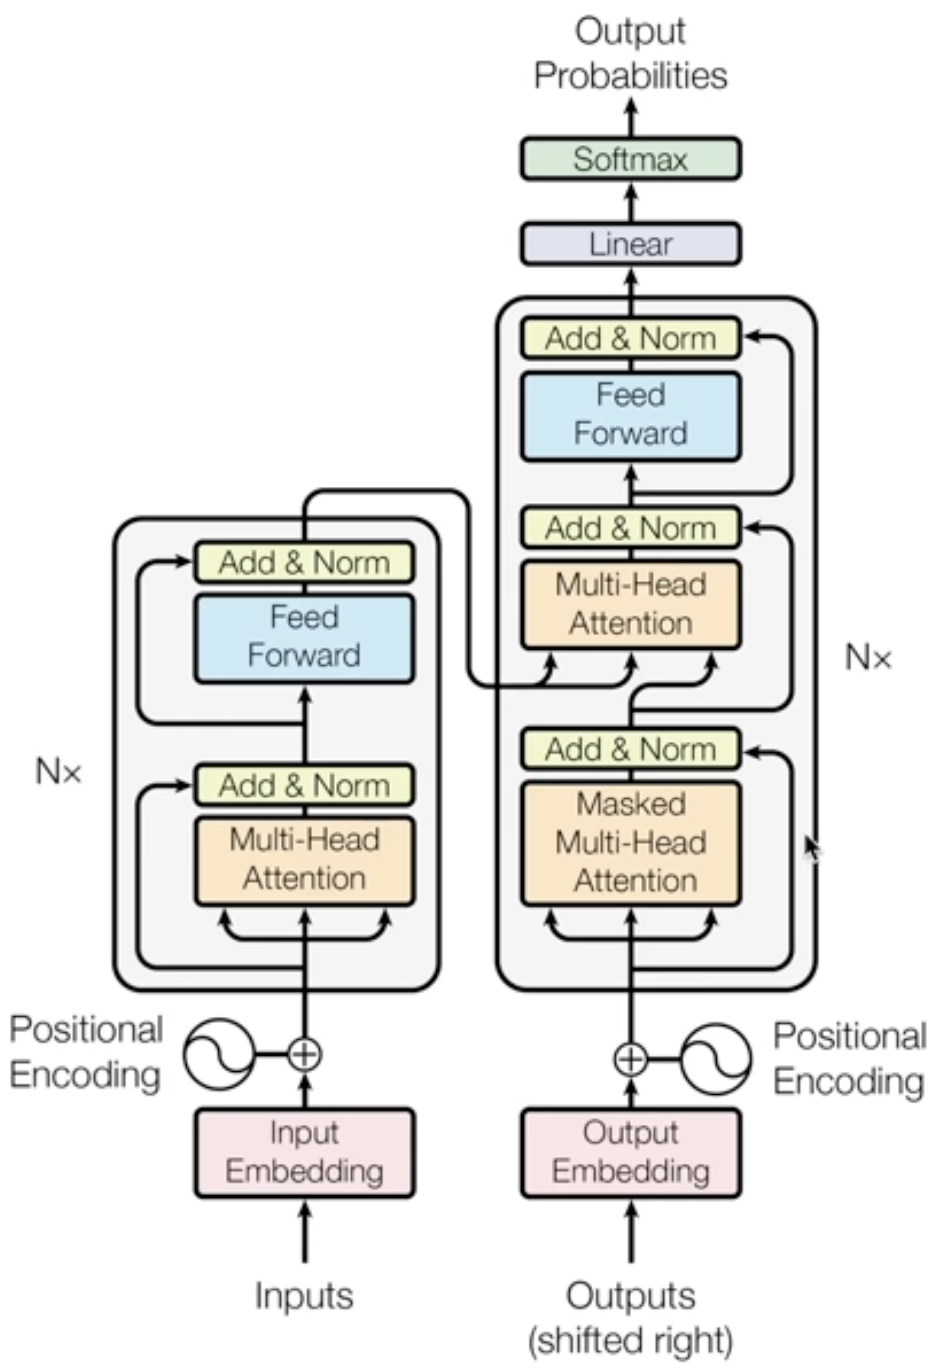  
This part is just a fully connected feed-forward NN. In the original paper, it consists of two linear transformations with a ReLU activation in between. This is where previously independently in parallel working nodes start to connect to each other.

In [42]:
class FeedForward(nn.Module):
    
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4*n_embd),  # the inner size is bigger (4*n_embd) because this is how was in the paper
            nn.ReLU(),
            nn.Linear(4*n_embd, n_embd),  # projection (just a linear transformation of the outcome of the layer)
            nn.Dropout(dropout),  # this we need as well
        )

    def forward(self, x):
        return self.net(x)

# transformer block
We combine self-attention block with the feed forward block into one big block called the transformer block.   
But we also need residual connections to each attention and feedforward block, as in the schema from the paper.

In [43]:
class Block(nn.Module):
    # combines both self-attention head(s) and proceeding fully connected feed-forward NN
    def __init__(self, n_embd, n_head):  # n_embd - embedding dimension; n_head: the number of self-attention heads
        super().__init__()
        head_size = n_embd // n_head
        # self-attention head(s)
        self.sa = MultiHeadAttention(n_head, head_size)
        # fully connected feed-forward NN
        self.ffwd = FeedForward(n_embd)
        # layer normalisation (pre-norm formulation)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))  # apply norm before the blocks; add residual connection at the end
        x = x + self.ffwd(self.ln2(x))  # apply norm before the blocks; add residual connection at the end
        return x

# bigram model architecture

In [44]:
class BigramLanguageModel(nn.Module):
    
    def __init__(self):
        super().__init__()  # vocab_size=len(chars)=65
        # word embedding
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)  # lookup table of size vocab_size * vocab_size. each 65 row is one token - a vector of 65 embedded values
        # position encoding
        self.position_embedding_table = nn.Embedding(block_size, n_embd)  # same size as logic as for lookup table
        # transformer blocks
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])  # how many such blocks do we want, each block includes both self-attention head(s) and proceeding fully connected feed-forward NN
        # final layer norm
        self.ln_f = nn.LayerNorm(n_embd)  # normalization at the end of the transformer and right before the final linear layer
        # linear layer
        self.lm_head = nn.Linear(n_embd, vocab_size)  # lm_head is short for language modeling head. linear layer simply performs matrix multiplication (output = x @ weight_matrix.T + b)
    
    # get predictions
    def forward(self, idx, targets=None):  # idx = input, targets = output
        # idx and targets are both 2D (B,T) tensors of integers (B batch=batch_size, T time=block_size) like [4,8] (see above inputs and targets example of shape 4*8)
        B, T = idx.shape
        # get word embeggings
        tok_emb = self.token_embedding_table(idx)  # (B,T,C). embedding layer turns every token ID into a vector of length C (vocab_size). So now it is 3D: (B,T,C) batch=batch_size, time=block_size, channels=vocab_size, like [4,8,65]
        # get position encodings
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T,C)
        # get combined values
        x = tok_emb + pos_emb  # (B,T,C)
        # gel values after transformer block(s) (get self-attention values & pass them through fully-connected feed-forward NN):
        x = self.blocks(x)  # (B,T,C)
        # get logits
        logits = self.lm_head(x)  # (B,T,vocab_size)
        
        # loss
        if targets == None:  # during generation we only want logits, no loss needed
            loss = None
        else:  # during training we compute loss
            # but F.cross_entropy() expects 2D input for preds and 1D for targets. Our target is (B,T), and logits are (B,T,C)...
            # Let's flatten our B and T dimensions into one big dimension:
            B, T, C = logits.shape   # unpack the shape: B=4, T=8, C=65
            logits = logits.view(B*T, C)  # reshape the 3D tensor into 2D: B*T=4*8=24 >> [24,65]
            targets = targets.view(B*T)  # reshape the 2D tensor into 1D: B*T=4*8=24 >> [24]
            # do not worry, the logic is safe: 1st row in logits (1st token - vector of size 65) corresponds to 1st row in targets (correct predict token)
            loss = F.cross_entropy(logits, targets)  # take each row in logits, compare it with the corresponding correct index in targets, return a single number (the average loss)
        return logits, loss  # return loss only if targets were provided

    # now let's generate smth from the model
    def generate(self, idx, max_new_tokens):   # idx is 2D (B, T) array, like [4,8]; max_new_tokens - how many new tokens to generate
        # goal is to take (B,T) and generate (B,T)+1,+2,+3...as many as we want max_new_tokens
        for _ in range(max_new_tokens):  # loop that appends one token at a time
            # crop idx to the last block size tokens
            idx_cond = idx[:, -block_size:]
            # get predictions:
            logits, loss = self(idx_cond)  # call forward. Since we don't pass targets, loss will be None (we don't need it at this stage)
            # for now, we are not interested in attention. We want only how the last token influences the target
            # therefore, for each batch (size 4), we need only the last token (last token's logits) and get rid of all tokens before it (all 7 out of 8) = overall 4 last tokens' logits per batch (size 4):
            logits = logits[:, -1, :]  # Python slicing takes: all 4 batches, only last tokens, all 65 logits of them. (B,T,C) becomes (B, C) >> [4,65] - 4 tokens (since batch_size 4) with 65 logits each
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # dim=-1 means apply softmax along the last dimension (the vocabulary dimension). probs are still (B, C)
            # sample one random token from the softmax probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # multinomial does weighted random sampling (higher probability tokens are more likely to be chosen) and returns one token index per sequence: (B, 1) ([4,1] since batch_size=4)
            # take chosen token and append it to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # torch.cat(..., dim=1) concatenates along the T dimension (B, T+1)
        return idx  # result after the loop >> idx contains the original tokens + all newly generated ones

# create model

In [45]:
model = BigramLanguageModel()
m = model.to(device)

# training

In [46]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# training
for iter in range(max_iters):  # increase number of steps for good results...
    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses ['val']:.4f}")
    # sample a batch of data
    xb, yb = get_batch('train')
    # evaluate the loss
    logits, loss = model(xb, yb)
    # zero our gradients from the previous step
    optimizer.zero_grad(set_to_none=True)
    # get gradients for all parameters
    loss.backward()
    # use those gradients to update parameters
    optimizer.step()

step 0: train loss 4.5361, val loss 4.5363
step 300: train loss 2.5015, val loss 2.5038
step 600: train loss 2.3791, val loss 2.3815
step 900: train loss 2.2929, val loss 2.3010
step 1200: train loss 2.2184, val loss 2.2441
step 1500: train loss 2.1914, val loss 2.2224
step 1800: train loss 2.1558, val loss 2.1934
step 2100: train loss 2.1264, val loss 2.1700
step 2400: train loss 2.1172, val loss 2.1599
step 2700: train loss 2.1091, val loss 2.1512
step 3000: train loss 2.0794, val loss 2.1256
step 3300: train loss 2.0623, val loss 2.1199
step 3600: train loss 2.0461, val loss 2.1099
step 3900: train loss 2.0523, val loss 2.1181
step 4200: train loss 2.0375, val loss 2.0897
step 4500: train loss 2.0293, val loss 2.0956
step 4800: train loss 1.9913, val loss 2.0790


# generate from the model

In [47]:
# create a starting context: a single sequence containing only token 0
context = torch.zeros((1, 1), dtype=torch.long, device=device)
# [0] selects the first sequence in the batch; tolist() converts PyTorch tensor into a list
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))



DUKE VINS:
Go poill, not I have not bing it is a not, you me ours?

VORUFINIE:
Rome brusping an EDWAPSBNEN:
I suints her oper
Shercenely not scapell'd plangain:
I was reas.

KING EDY ARK OF VINCENV:
We doth
I the I ambair, think,
Ans his too me:
Grotled proplacess than wa?
By cozes: yet deefen to sir:
Ten optars that iwith chath, betute;
Lut rapurs of nast am.
Buk I chy ke yemo ceviles;
But Combe not hes;
This that and I thomss they your ins like of them's the he revigo ned han you foingle foul
